<a href="https://colab.research.google.com/github/adel-lopez/projet-analyse-tesla-byd-renault/blob/main/projet_analyse_TESLA_BYD_RENAULT_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install reportlab
!pip install --upgrade yfinance
!pip install python-pptx
!pip install -U pandas plotly openpyxl python-pptx kaleido
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
from google.colab import files
from IPython.display import display
from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
import time
from pptx import Presentation
from pptx.util import Inches, Pt
from reportlab.lib import colors as rl_colors
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle, PageBreak
from reportlab.lib.styles import getSampleStyleSheet
from pptx.dml.color import RGBColor
from pptx.enum.shapes import MSO_AUTO_SHAPE_TYPE
import plotly.figure_factory as ff
import plotly.io as pio
import plotly.graph_objs as go

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.8/137.8 kB 3.9 MB/s eta 0:00:00
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.66
    Uninstalling yfinance-0.2.66:
      Successfully uninstalled yfinance-0.2.66
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 13.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successful

Cours Tesla


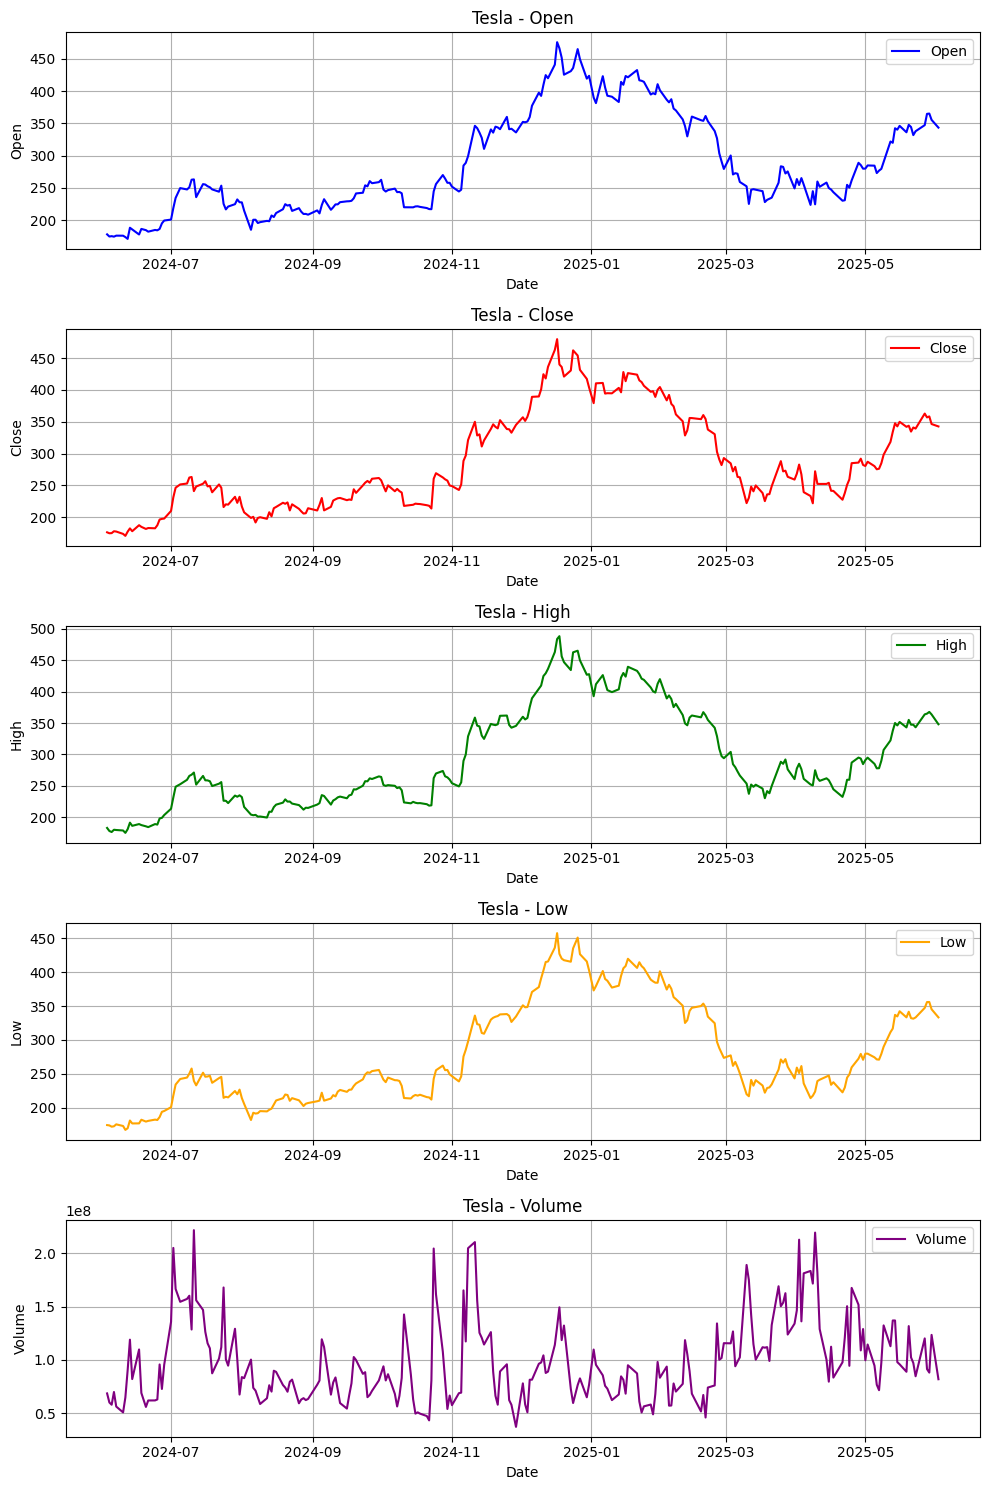

In [15]:

data = yf.Ticker("TSLA")

time.sleep(1)

df = data.history(start="2024-06-02", end="2025-06-03")

open_price = df['Open']
close_price = df['Close']
high_price = df['High']
low_price = df['Low']
volume = df['Volume']

fig, axes = plt.subplots(5, 1, figsize=(10, 15))

donnees = [open_price, close_price, high_price, low_price, volume]
labels = ['Open', 'Close', 'High', 'Low', 'Volume']
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, serie in enumerate(donnees):
    axes[i].plot(serie, label=labels[i], color=colors[i])
    axes[i].legend()
    axes[i].grid(True)
    axes[i].set_ylabel(labels[i])
    axes[i].set_xlabel('Date')
    axes[i].set_title(f'Tesla - {labels[i]}')

plt.tight_layout()
plt.show()


Excel cours Tesla BYD Renault


In [25]:

tickers = ["1211.HK", "RNL.F", "TSLA"]

time.sleep(1)

data = yf.download(tickers,start="2024-06-02",end="2025-06-03")

prix_ouverture = pd.DataFrame({
    "BYD": data["Close"]["1211.HK"],
    "Renault": data["Close"]["RNL.F"],
    "Tesla": data["Close"]["TSLA"],
})

display(prix_ouverture)

prix_ouverture.to_excel("Close_prices_2024_2025.xlsx", index=True)
files.download("Close_prices_2024_2025.xlsx")


[*********************100%***********************]  3 of 3 completed


,BYD,Renault,Tesla
Date,,,
2024-06-03,74.534767,47.683369,176.289993
2024-06-04,74.599403,46.956867,174.770004
2024-06-05,75.439781,46.070885,175.000000
2024-06-06,74.082253,46.159485,177.940002
2024-06-07,73.694389,44.936836,177.479996
...,...,...,...
2025-05-27,137.220947,44.321362,362.890015
2025-05-28,133.546005,43.178963,356.899994
2025-05-29,133.217850,43.160385,358.429993


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Graphique de l'évolution du cours de fermeture

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  2 of 2 completed


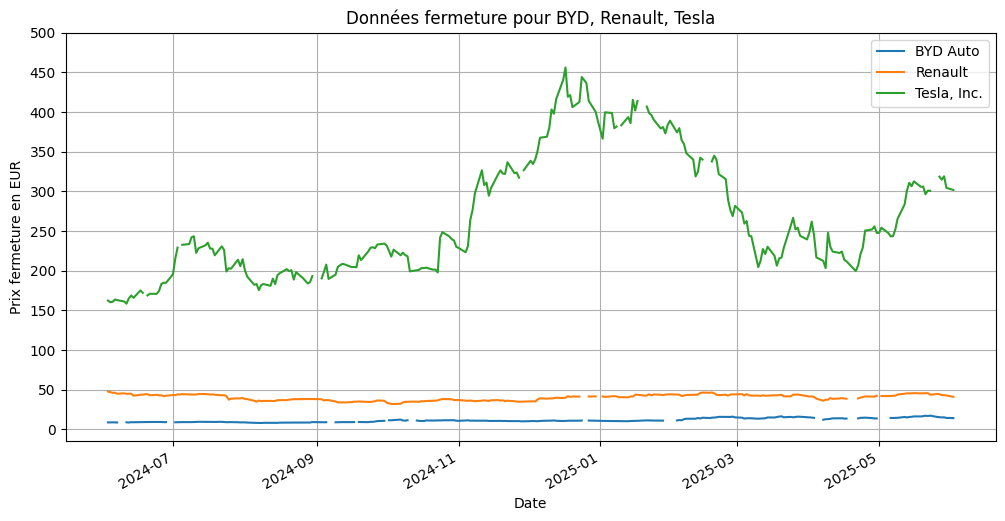

In [30]:

tickers = ["1211.HK", "RNL.F", "TSLA"]

start_date = "2024-06-02"
end_date = "2025-06-03"

time.sleep(1)

# Données actions
data = yf.download(tickers, start=start_date, end=end_date)

Close_data = data["Close"].copy()

# Taux de change sur la même période
fx = yf.download(
    ["HKDEUR=X", "USDEUR=X"],
    start=start_date,
    end=end_date
)["Close"]

# Alignement des dates
fx = fx.reindex(Close_data.index).ffill().bfill()

# Conversion en euros
Close_data["1211.HK"] = Close_data["1211.HK"] * fx["HKDEUR=X"]
Close_data["TSLA"] = Close_data["TSLA"] * fx["USDEUR=X"]

# Renommer les colonnes pour le graphique
Close_data = Close_data.rename(columns={
    "1211.HK": "BYD Auto",
    "RNL.F": "Renault",
    "TSLA": "Tesla, Inc."
})

fig, ax = plt.subplots(figsize=(12, 6))

Close_data.plot(ax=ax)

ax.set_title("Données fermeture pour BYD, Renault, Tesla")
ax.set_xlabel("Date")
ax.set_ylabel("Prix fermeture en EUR")
plt.yticks(np.arange(0, Close_data.max().max() + 50, 50))

ax.legend()
ax.grid(True)

plt.savefig("cours_des_3snf.png")
plt.show()

Evolution en base 100

[*********************100%***********************]  3 of 3 completed


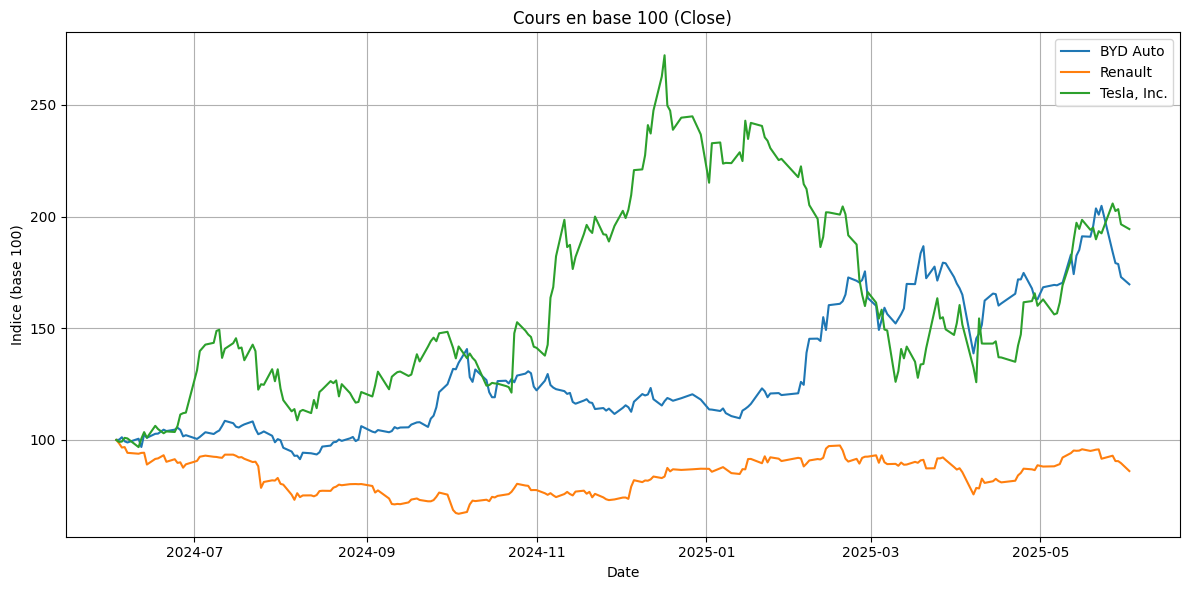

In [28]:


tickers = ["1211.HK", "RNL.F", "TSLA"]
time.sleep(1)
data = yf.download(tickers,start="2024-06-02",end="2025-06-03")
Close_data = data["Close"].dropna()

base100 = Close_data / Close_data.iloc[0] * 100

plt.figure(figsize=(12, 6))
for column in base100.columns:
    plt.plot(base100.index, base100[column], label=column)

plt.title("Cours en base 100 (Close)")
plt.xlabel("Date")
plt.ylabel("Indice (base 100)")
plt.legend(["BYD Auto", "Renault", "Tesla, Inc."])
plt.grid(True)
plt.grid(True)
plt.tight_layout()

plt.savefig("evo-base100.png")
plt.show()


Beta de chaque action

[*********************100%***********************]  2 of 2 completed


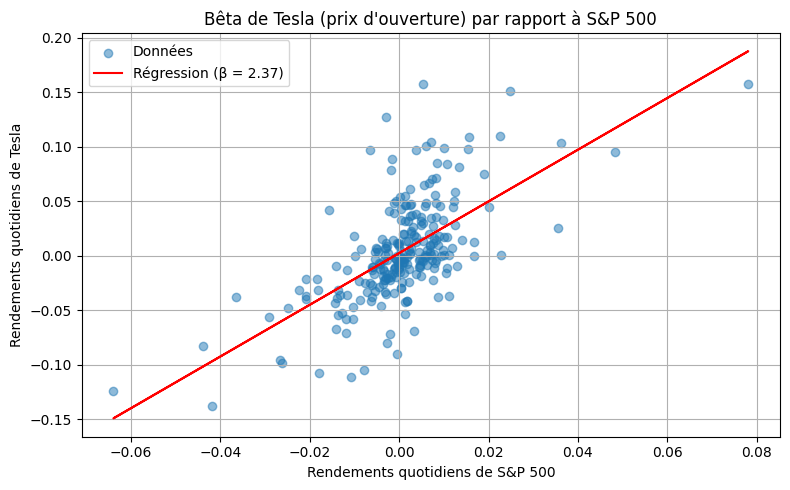

[*********************100%***********************]  2 of 2 completed


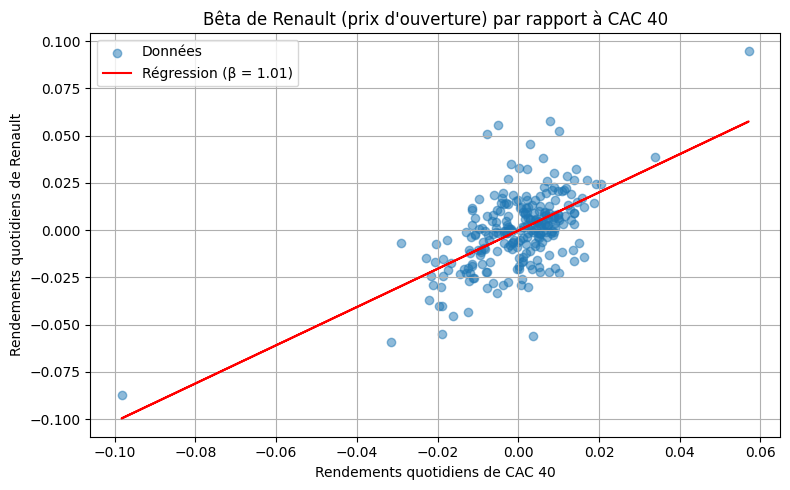

[*********************100%***********************]  2 of 2 completed


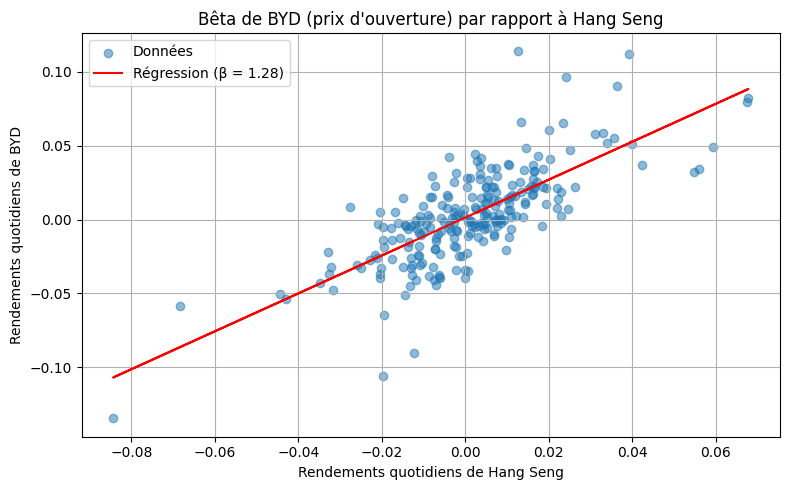


--- Résumé des bêtas (avec prix d'ouverture) ---
Tesla : 2.3696710611769434
Renault : 1.0108920065242393
BYD : 1.284716561419492


In [29]:
assets_indices = {
    "TSLA": "GSPC",
    "RNL.F": "FCHI",
    "1211.HK": "HSI",
}

asset_names = {
    "TSLA": "Tesla",
    "RNL.F": "Renault",
    "1211.HK": "BYD"
}

index_names = {
    "GSPC": "S&P 500",
    "FCHI": "CAC 40",
    "HSI": "Hang Seng"
}

start_date = "2024-06-02"
end_date = "2025-06-03"

betas = {}

for asset, index in assets_indices.items():
    try:
        time.sleep(1)
        data = yf.download([asset, f"^{index}"], start=start_date, end=end_date)["Close"].dropna()

        if data.shape[1] != 2:
            raise ValueError("Données manquantes pour action ou indice.")

        data.columns = ['Asset', 'Index']
        returns = data.pct_change().dropna()

        X = sm.add_constant(returns["Index"])
        model = sm.OLS(returns["Asset"], X).fit()
        beta = model.params["Index"]
        betas[asset] = beta

        asset_label = asset_names.get(asset, asset)
        index_label = index_names.get(index, index)

        plt.figure(figsize=(8, 5))
        plt.scatter(returns["Index"], returns["Asset"], alpha=0.5, label='Données')
        plt.plot(returns["Index"], model.predict(X), color='red', label=f"Régression (β = {beta:.2f})")
        plt.title(f"Bêta de {asset_label} (prix d'ouverture) par rapport à {index_label}")
        plt.xlabel(f"Rendements quotidiens de {index_label}")
        plt.ylabel(f"Rendements quotidiens de {asset_label}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        betas[asset] = f"Erreur : {e}"

print("\n--- Résumé des bêtas (avec prix d'ouverture) ---")
for ticker, beta in betas.items():
    print(f"{asset_names.get(ticker, ticker)} : {beta}")

Matrice de correlation

In [38]:
tickers = ["TL0.F", "RNL.F", "1211.HK"]

start_date = "2024-06-02"
end_date = "2025-06-03"

time.sleep(1)

df = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False
)["Close"]

df = df.rename(columns={
    "TL0.F": "Tesla",
    "RNL.F": "Renault",
    "1211.HK": "BYD"
})

returns = df.pct_change(fill_method=None).dropna()

correlation_matrix = returns.corr()

print(correlation_matrix)

[*********************100%***********************]  3 of 3 completed

Ticker        BYD   Renault     Tesla
Ticker                               
BYD      1.000000  0.122710  0.019319
Renault  0.122710  1.000000  0.112958
Tesla    0.019319  0.112958  1.000000


informations fianncières

In [39]:
tickers = ["TL0.F", "RNL.F", "1211.HK"]
time.sleep(1)


financial_data = {}


for ticker in tickers:
    stock = yf.Ticker(ticker)

    info = stock.info


    financial_data[ticker] = {
        'Company': info.get('longName', 'N/A'),
        'Market Cap': info.get('marketCap', 'N/A'),
        'PE Ratio': info.get('trailingPE', 'N/A'),
        'Dividend Yield': info.get('dividendYield', 'N/A'),
        'Revenue': info.get('totalRevenue', 'N/A'),
        'Profit': info.get('grossProfits', 'N/A'),
        'Profit Margin': info.get('profitMargins', 'N/A'),
        'Beta': info.get('beta', 'N/A'),
        'Shares Outstanding': info.get('sharesOutstanding', 'N/A'),
        '52 Week High': info.get('fiftyTwoWeekHigh', 'N/A'),
        '52 Week Low': info.get('fiftyTwoWeekLow', 'N/A'),
        'Currency': info.get('currency', 'N/A'),
        'Industry': info.get('industry', 'N/A'),
        'Sector': info.get('sector', 'N/A'),
        'Country': info.get('country', 'N/A')
    }


Close_prices = yf.download(tickers,start="2024-06-02",end="2025-06-03")['Close']

mean_Close = Close_prices.mean()
std_Close = Close_prices.std()


financial_df = pd.DataFrame(financial_data).T  # avoir tickers en lignes
financial_df['Mean '] = mean_Close
financial_df['Std '] = std_Close


financial_df.to_excel("financial_data.xlsx", index=True)

print("Données financières exportées dans 'financial_data.xlsx'")
files.download('financial_data.xlsx')

[*********************100%***********************]  3 of 3 completed

Données financières exportées dans 'financial_data.xlsx'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PDF : mise au propre et analyse

In [37]:


# Fonction de formatage
def format_value(value, value_type='number'):
    if value is None or value == 'N/A':
        return "N/A"
    try:
        if value_type == 'money':
            return f"{value / 1e9:.2f} Md"
        elif value_type == 'percent':
            return f"{value * 100:.1f} %"
        elif value_type == 'number':
            return f"{value:,.1f}"
        else:
            return str(value)
    except:
        return "N/A"


tickers = ["TSLA", "RNL.F", "1211.HK"]
time.sleep(1)
data = yf.download(tickers,start="2024-06-02",end="2025-06-03")["Close"]
returns = data.pct_change().dropna()


correlation_matrix = returns.corr()

base100 = data / data.iloc[0] * 100
plt.figure(figsize=(10, 6))
for column in base100.columns:
    plt.plot(base100.index, base100[column], label=column)
plt.title("Rendements en base 100")
plt.xlabel("Date")
plt.ylabel("Prix en base 100")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("rendements_base100.png")
plt.close()


plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation des rendements")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.close()


financial_data = []
for ticker in tickers:
    stock = yf.Ticker(ticker)
    info = stock.info
    financial_data.append([
        info.get('longName', 'N/A'),  # Nom de l'entreprise
        ticker,
        format_value(info.get('marketCap'), 'money'),
        format_value(info.get('totalRevenue'), 'money'),
        format_value(info.get('netIncomeToCommon'), 'money'),
        format_value(info.get('trailingPE'), 'number'),
        format_value(info.get('dividendYield'), 'percent'),
        format_value(info.get('revenueGrowth'), 'percent'),
        info.get('currency', 'N/A')
    ])

columns = [
    "Entreprise",
    "Ticker",
    "Market Cap",
    "Revenue",
    "Net Income",
    "PE Ratio",
    "Dividend Yield",
    "Revenue Growth",
    "Devise"
]

financial_df = pd.DataFrame(financial_data, columns=columns)


styles = getSampleStyleSheet()
doc = SimpleDocTemplate("rapport_financier.pdf", pagesize=letter)
elements = []

# Page 1 - Titre
elements.append(Paragraph("Rapport Financier - Analyse des Actions 2024 ", styles['Title']))
elements.append(Spacer(1, 30))
elements.append(Paragraph("Ce rapport présente une analyse comparative de plusieurs entreprises du secteur des voitures electriques.", styles['Normal']))
elements.append(PageBreak())

# Page 2 - Graphique
elements.append(Paragraph("1. Graphique des rendements en base 100", styles['Heading2']))
elements.append(Image("rendements_base100.png", width=400, height=200))
elements.append(Paragraph("On peut constater que malgré la forte baisse de Tesla en janvier, le secteur électrique est en hausse.", styles['Normal']))
elements.append(PageBreak())

# Page 3 - Corrélation
elements.append(Paragraph("2. Matrice de corrélation des rendements", styles['Heading2']))
elements.append(Image("correlation_heatmap.png", width=400, height=200))
elements.append(Spacer(1, 12))
elements.append(Paragraph("On peut constater que les actions ne sont pas corrélées. Le cours d'une des actions influences que tres peu le cours des 2 autres", styles['Normal']))
elements.append(PageBreak())

# Page 4 - Données financières
elements.append(Paragraph("3. Données Financières Synthétiques", styles['Heading2']))
table_data = [financial_df.columns.tolist()] + financial_df.values.tolist()
table = Table(table_data, repeatRows=1, hAlign='LEFT')
table.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), rl_colors.white),
    ('TEXTCOLOR', (0, 0), (-1, 0), rl_colors.black),
    ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
    ('GRID', (0, 0), (-1, -1), 0.5, rl_colors.grey),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('FONTSIZE', (0, 0), (-1, -1), 8),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [rl_colors.whitesmoke, rl_colors.lightgrey]),
]))
elements.append(table)
elements.append(PageBreak())

# Page 5 - Conclusion
elements.append(Paragraph("4. Conclusion", styles['Heading2']))
conclusion_text = [
    "<b>1. Tesla (TSLA)</b>",
    "Forces : Très forte capitalisation boursière, rentabilité élevée, leader mondial des véhicules électriques, forte valorisation (PE très élevé), croissance attendue à long terme.",
    "Faiblesses : Chiffre d’affaires en recul (-9,2 %), pas de dividende, dépendance à l’innovation pour justifier sa valorisation.",
    "Idéal pour : les investisseurs orientés croissance long terme, prêts à accepter de la volatilité.",
    "",
    "<b>2. Renault (RNLF)</b>",
    "Forces : Entreprise rentable, dividendes très élevés (même si probablement exceptionnels), valorisation faible (PE bas), croissance modérée du chiffre d’affaires.",
    "Faiblesses : Faible performance boursière (+3,62 %), petite capitalisation comparée aux concurrents, manque de dynamisme à l’international.",
    "Idéal pour : les investisseurs à la recherche de revenus (dividendes), avec un profil prudent.",
    "",
    "<b>3. BYD Company (1211.HK)</b>",
    "Forces : Meilleure croissance du chiffre d’affaires (+36,3 %), excellente performance boursière (+70,53 %), bonne rentabilité, dividendes intéressants, fort positionnement en Chine.",
    "Faiblesses : Moins connu en Europe, plus exposé à la concurrence locale, dividende peut-être exceptionnel.",
    "Idéal pour : les investisseurs en quête de croissance solide et diversification internationale, surtout en Asie.",
    "",
    "<b>Conclusion générale</b>",
    "Tesla : le choix du futur et de l’innovation.",
    "Renault : un pari stable, centré sur le rendement.",
    "BYD : la star montante, en forte expansion."
]
for line in conclusion_text:
    elements.append(Paragraph(line, styles['Normal']))
    elements.append(Spacer(1, 6))


doc.build(elements)
print("✅ Rapport PDF avec note de corrélation généré avec succès.")
files.download('rapport_financier.pdf')


[*********************100%***********************]  3 of 3 completed


✅ Rapport PDF avec note de corrélation généré avec succès.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>